In [2]:
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

In [29]:
df = pd.read_csv('/content/datasetCrime.csv', on_bad_lines='skip', engine='python')

print(df.shape)
display(df.head())

(93686, 3)


,category,sub_category,crimeaditionalinfo
0,Online and Social Media Related Crime,Cyber Bullying Stalking Sexting,I had continue received random calls and abusi...
1,Online Financial Fraud,Fraud CallVishing,The above fraudster is continuously messaging ...
2,Online Gambling Betting,Online Gambling Betting,He is acting like a police and demanding for m...
3,Online and Social Media Related Crime,Online Job Fraud,In apna Job I have applied for job interview f...
4,Online Financial Fraud,Fraud CallVishing,I received a call from lady stating that she w...


In [30]:
df = df.dropna(subset=['crimeaditionalinfo', 'category'])
df = df.drop_duplicates()

print(df.shape)

(85876, 3)


In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['crimeaditionalinfo'].apply(clean_text)

df[['crimeaditionalinfo', 'clean_text']].head()

,crimeaditionalinfo,clean_text
0,I had continue received random calls and abusi...,i had continue received random calls and abusi...
1,The above fraudster is continuously messaging ...,the above fraudster is continuously messaging ...
2,He is acting like a police and demanding for m...,he is acting like a police and demanding for m...
3,In apna Job I have applied for job interview f...,in apna job i have applied for job interview f...
4,I received a call from lady stating that she w...,i received a call from lady stating that she w...


In [7]:
def make_binary_category(cat):
    cat = str(cat).lower()

    if 'financial' in cat or 'fraud' in cat:
        return 'Financial Fraud'
    else:
        return 'Non Financial Cybercrime'

df['binary_category'] = df['category'].apply(make_binary_category)

df['binary_category'].value_counts()

,count
binary_category,
Financial Fraud,35779
Non Financial Cybercrime,22626


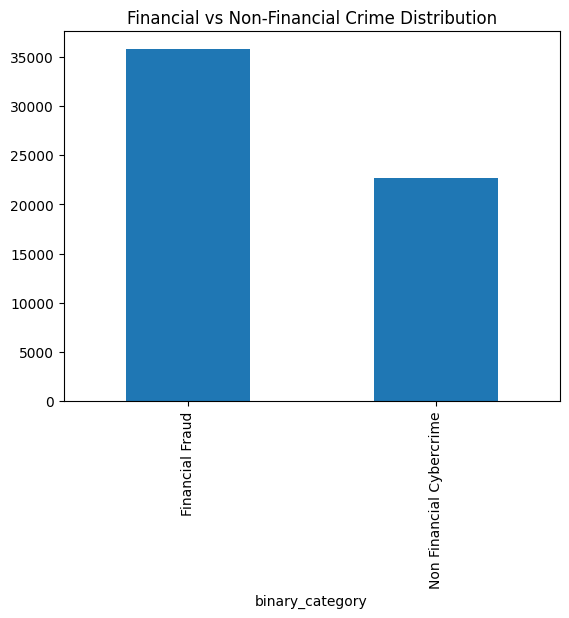

In [20]:
import matplotlib.pyplot as plt

df['binary_category'].value_counts().plot(
    kind='bar'
)

plt.title("Financial vs Non-Financial Crime Distribution")
plt.show()

In [8]:
X = df['clean_text']
y = df['binary_category']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(46724,)
(11681,)


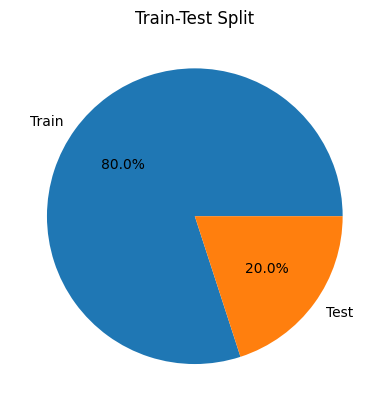

In [21]:
sizes = [len(X_train), len(X_test)]

plt.pie(
    sizes,
    labels=["Train","Test"],
    autopct="%1.1f%%"
)

plt.title("Train-Test Split")
plt.show()

In [9]:
tfidf = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [11]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Shape of X_train_tfidf:", X_train_tfidf.shape)
print("Shape of X_test_tfidf:", X_test_tfidf.shape)

Shape of X_train_tfidf: (46724, 100000)
Shape of X_test_tfidf: (11681, 100000)


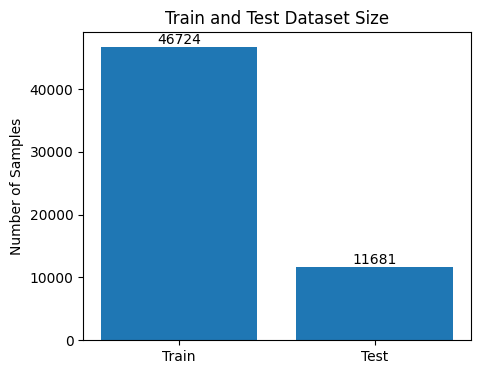

In [45]:
import matplotlib.pyplot as plt

datasets = ['Train', 'Test']
samples = [46724, 11681]

plt.figure(figsize=(5,4))
plt.bar(datasets, samples)

plt.title("Train and Test Dataset Size")
plt.ylabel("Number of Samples")

for i, v in enumerate(samples):
    plt.text(i, v+500, str(v), ha='center')

plt.show()

In [15]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(
    loss='modified_huber',
    alpha=1e-5,
    max_iter=5000,
    random_state=42
)

sgd.fit(X_train_tfidf, y_train)

pred = sgd.predict(X_test_tfidf)

print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8285249550552178
                          precision    recall  f1-score   support

         Financial Fraud       0.85      0.87      0.86      7156
Non Financial Cybercrime       0.79      0.76      0.77      4525

                accuracy                           0.83     11681
               macro avg       0.82      0.82      0.82     11681
            weighted avg       0.83      0.83      0.83     11681



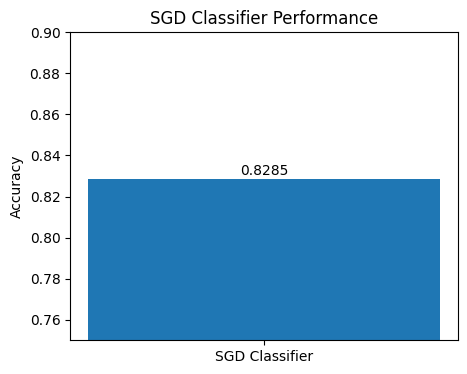

In [31]:
import matplotlib.pyplot as plt

model = ['SGD Classifier']
accuracy = [0.8285]

plt.figure(figsize=(5,4))

plt.bar(model, accuracy)

plt.ylabel("Accuracy")
plt.title("SGD Classifier Performance")

plt.ylim(0.75, 0.90)

plt.text(0, accuracy[0]+0.002,
         f"{accuracy[0]:.4f}",
         ha='center')

plt.show()

In [13]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)
nb_pred = nb.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.8370858659361357
                          precision    recall  f1-score   support

         Financial Fraud       0.83      0.92      0.87      7156
Non Financial Cybercrime       0.85      0.70      0.77      4525

                accuracy                           0.84     11681
               macro avg       0.84      0.81      0.82     11681
            weighted avg       0.84      0.84      0.83     11681



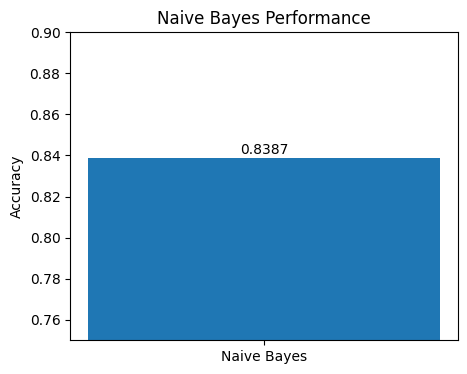

In [39]:
import matplotlib.pyplot as plt

model = ['Naive Bayes']
accuracy = [0.838708]

plt.figure(figsize=(5,4))

plt.bar(model, accuracy)

plt.ylabel("Accuracy")
plt.title("Naive Bayes Performance")

plt.ylim(0.75, 0.90)

plt.text(0, accuracy[0]+0.002,
         f"{accuracy[0]:.4f}",
         ha='center')

plt.show()

In [40]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    C=10, # Increased C to reduce regularization, aiming for higher accuracy
    max_iter=5000,
    solver='saga',
    n_jobs=-1
)

lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8414519304854037
                          precision    recall  f1-score   support

         Financial Fraud       0.86      0.89      0.87      7156
Non Financial Cybercrime       0.81      0.77      0.79      4525

                accuracy                           0.84     11681
               macro avg       0.84      0.83      0.83     11681
            weighted avg       0.84      0.84      0.84     11681



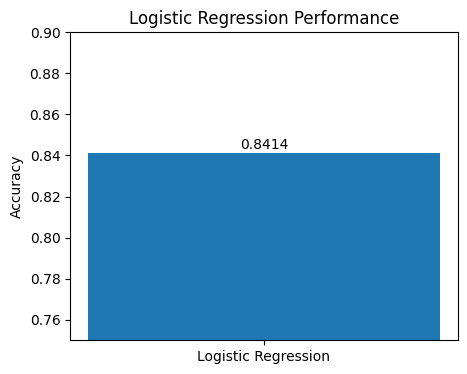

In [41]:
import matplotlib.pyplot as plt

model = ['Logistic Regression']
accuracy = [0.8414]

plt.figure(figsize=(5,4))

plt.bar(model, accuracy)

plt.ylabel("Accuracy")
plt.title("Logistic Regression Performance")

plt.ylim(0.75, 0.90)

plt.text(0, accuracy[0]+0.002,
         f"{accuracy[0]:.4f}",
         ha='center')

plt.show()

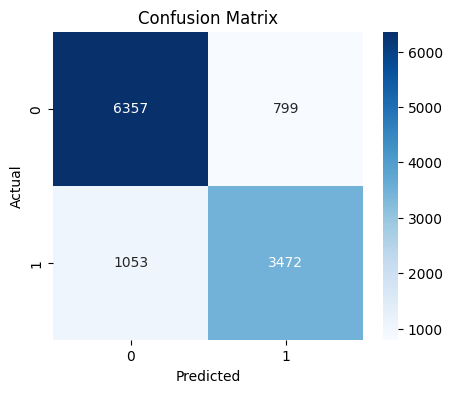

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    C=1,
    max_iter=5000
)

svm.fit(X_train_tfidf, y_train)
svm_pred = svm.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.8390548754387467
                          precision    recall  f1-score   support

         Financial Fraud       0.86      0.89      0.87      7156
Non Financial Cybercrime       0.81      0.76      0.79      4525

                accuracy                           0.84     11681
               macro avg       0.83      0.83      0.83     11681
            weighted avg       0.84      0.84      0.84     11681



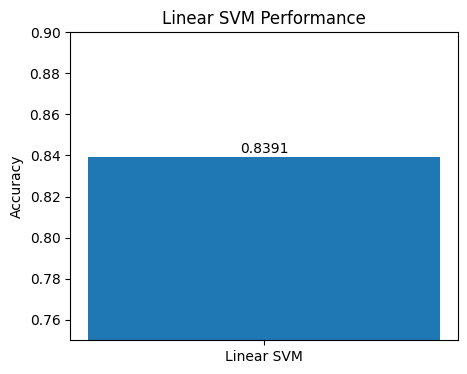

In [35]:
import matplotlib.pyplot as plt

model = ['Linear SVM']
accuracy = [0.8391]

plt.figure(figsize=(5,4))

plt.bar(model, accuracy)

plt.ylabel("Accuracy")
plt.title("Linear SVM Performance")

plt.ylim(0.75, 0.90)

plt.text(0, accuracy[0]+0.002,
         f"{accuracy[0]:.4f}",
         ha='center')

plt.show()

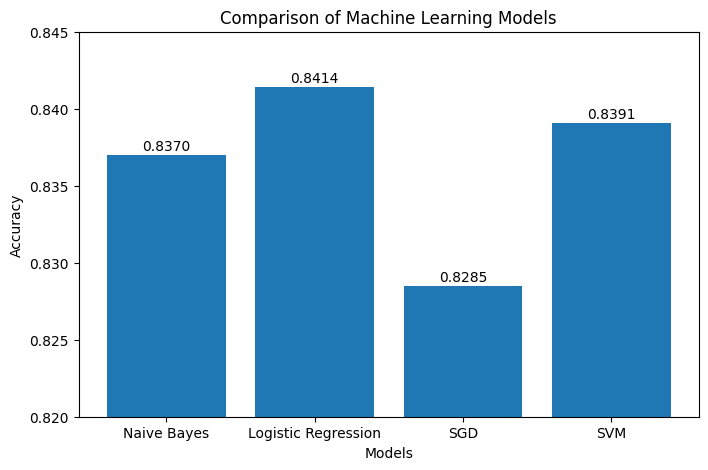

In [43]:
import matplotlib.pyplot as plt

models = [
    'Naive Bayes',
    'Logistic Regression',
    'SGD',
    'SVM'
]

scores = [
    0.8370,
    0.8414,
    0.8285,
    0.8391
]

plt.figure(figsize=(8,5))

bars = plt.bar(models, scores)

plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Comparison of Machine Learning Models")

# Zoomed range
plt.ylim(0.82, 0.845)

for i, v in enumerate(scores):
    plt.text(i, v+0.0003,
             f"{v:.4f}",
             ha='center')

plt.show()